In [3]:
import numpy as np
import pandas as pd

uid = "CA"

jr = joint_out.results[uid]
inp = jr.cdc_inputs
out = jr.cdc_output
params = cdc_loader.load_point_estimates(uid)

years = np.asarray(inp.years)

# intermediates reconstructed from current predictor equations
prep_on = np.asarray(inp.prep_on, dtype=float)
tau = np.asarray(inp.tau, dtype=float)
N_elig = np.asarray(inp.N_elig, dtype=float)

prep_on_count_calc = params.kappa_prep * prep_on * N_elig
prep_off_count_calc = N_elig - prep_on_count_calc
incidence_calc = params.beta * prep_off_count_calc
delta_calc = 1.0 - np.exp(-params.kdx * tau)

# compare to model outputs
df = pd.DataFrame({
    "year": years,
    "prep_on_input": prep_on,
    "tau_input": tau,
    "N_elig": N_elig,
    "kappa_prep": params.kappa_prep,
    "prep_on_count_calc": prep_on_count_calc,
    "prep_on_count_out": out.prep_on_count,
    "prep_off_count_calc": prep_off_count_calc,
    "beta": params.beta,
    "incidence_calc": incidence_calc,
    "incidence_out": out.incidence,
    "kdx": params.kdx,
    "delta_calc": delta_calc,
    "diagnosed_out": out.diagnosed,
    "undiagnosed_out": out.undiagnosed,
})

# nicer display
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
display(df)

print("\nQuick ranges:")
for c in [
    "prep_on_input", "tau_input", "N_elig",
    "prep_on_count_out", "incidence_out", "diagnosed_out", "undiagnosed_out"
]:
    print(f"{c:20s} min={df[c].min():,.4f}  max={df[c].max():,.4f}")


,year,prep_on_input,tau_input,N_elig,kappa_prep,prep_on_count_calc,prep_on_count_out,prep_off_count_calc,beta,incidence_calc,incidence_out,kdx,delta_calc,diagnosed_out,undiagnosed_out
0,2017,0.1810,1.2596,"446,585.6854",0.9527,"77,033.2780","77,033.2780","369,552.4074",0.0106,"3,914.5088","3,914.5088",0.0550,0.0669,"5,069.7845","75,809.1653"
1,2018,0.2278,1.1801,"487,961.1017",0.9527,"105,921.9939","105,921.9939","382,039.1077",0.0106,"4,046.7750","4,046.7750",0.0550,0.0628,"4,687.7204","74,653.8896"
2,2019,0.2746,1.1065,"493,133.1805",0.9527,"129,026.9661","129,026.9661","364,106.2144",0.0106,"3,856.8196","3,856.8196",0.0550,0.0590,"4,366.3587","74,012.9442"
3,2020,0.3214,1.0380,"535,019.1213",0.9527,"163,835.7139","163,835.7139","371,183.4074",0.0106,"3,931.7853","3,931.7853",0.0550,0.0554,"4,075.2481","73,503.4051"
4,2021,0.3545,1.0394,"571,732.9834",0.9527,"193,097.7974","193,097.7974","378,635.1860",0.0106,"4,010.7187","4,010.7187",0.0550,0.0555,"4,072.6907","73,359.9422"
5,2022,0.3876,1.0408,"606,590.5299",0.9527,"223,988.6562","223,988.6562","382,601.8737",0.0106,"4,052.7361","4,052.7361",0.0550,0.0556,"4,074.6495","73,297.9702"



Quick ranges:
prep_on_input        min=0.1810  max=0.3876
tau_input            min=1.0380  max=1.2596
N_elig               min=446,585.6854  max=606,590.5299
prep_on_count_out    min=77,033.2780  max=223,988.6562
incidence_out        min=3,856.8196  max=4,052.7361
diagnosed_out        min=4,072.6907  max=5,069.7845
undiagnosed_out      min=73,297.9702  max=75,809.1653


In [8]:
from models.shared.transforms import hazard_proxy
hazard_proxy(0.837)

np.float64(1.8140050781753745)

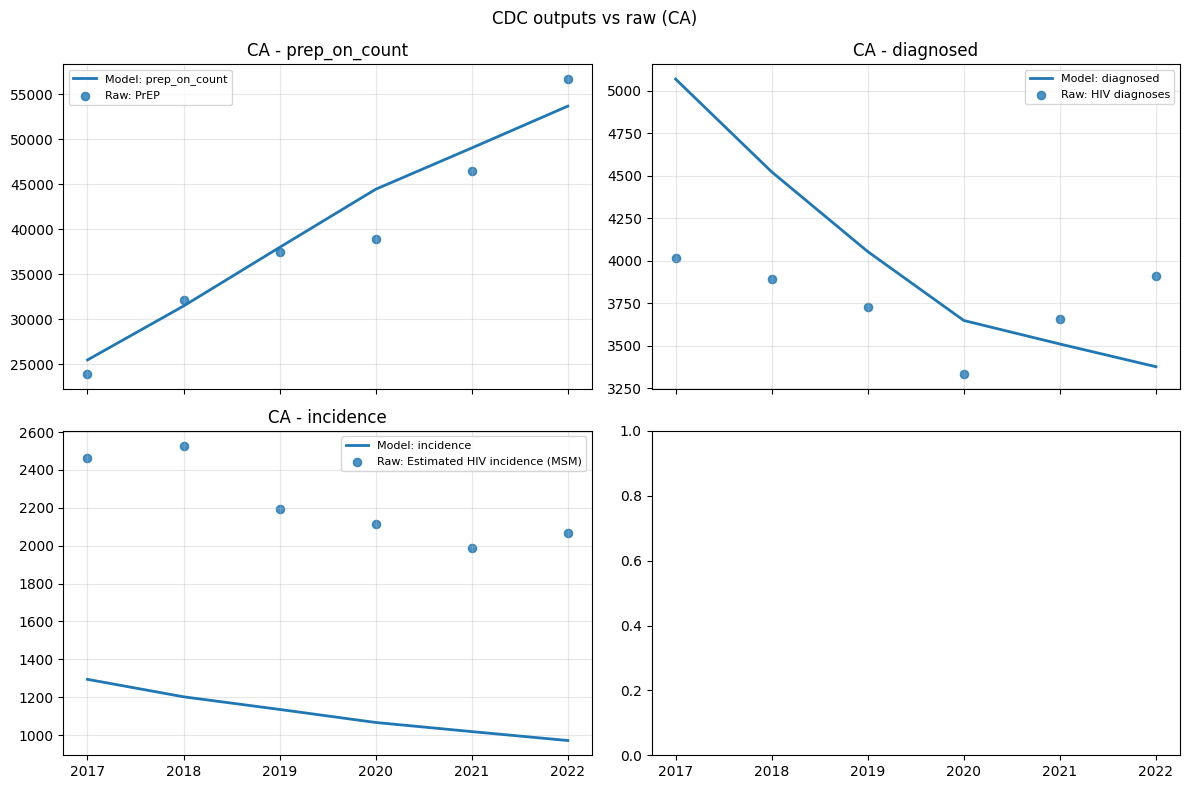

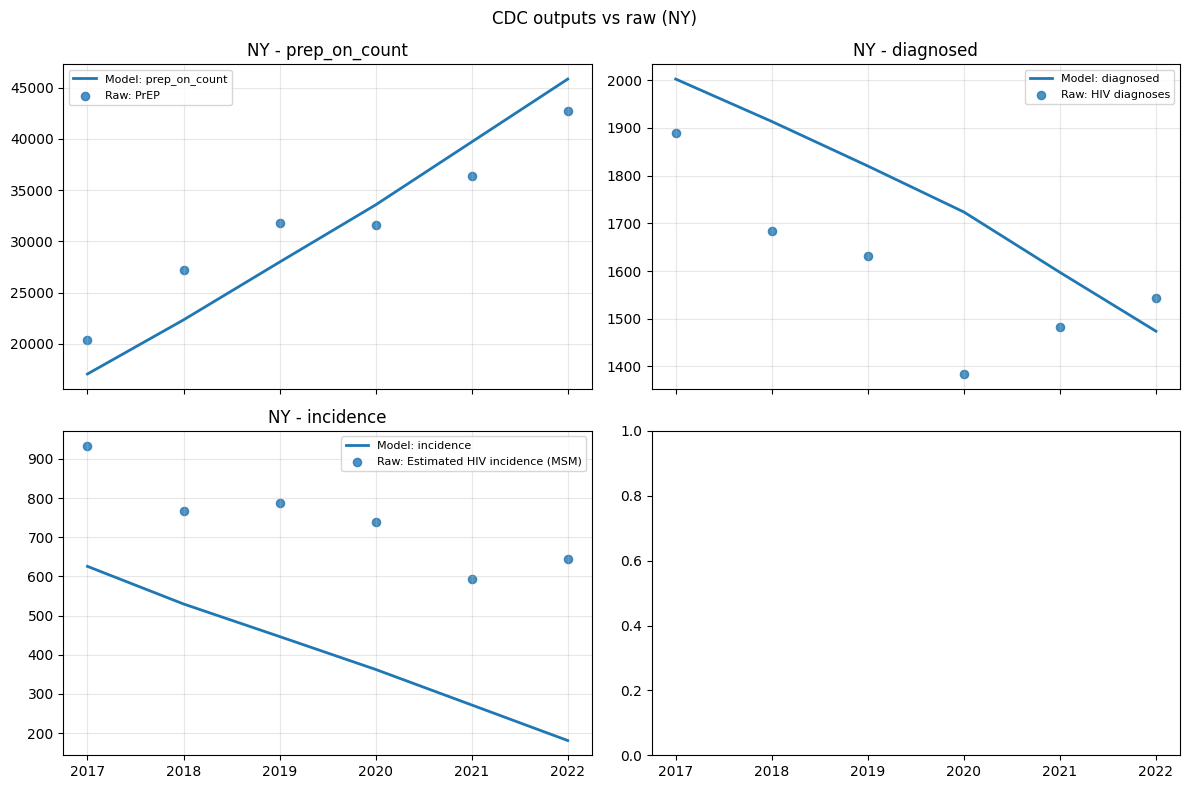

In [4]:
from pathlib import Path

from data.data_prep import DataPrep
from config.base import BaseConfig
from data.params_cdc import CDCParamsLoader
from engine.joint_runner import load_sem_output, build_units_dict, run_joint

# 1) Prepare data (for units + CDC inputs by geography)
config = BaseConfig()   # no "..."
prep = DataPrep(config)
prepared = prep.prepare_inputs()

# 2) Load SEM output + CDC posterior params
sem_output = load_sem_output(Path("output/output.pkl"))
cdc_loader = CDCParamsLoader(
    Path("cdc_posteriors.nc"),
    Path("trans_results.npz"),
)
units = build_units_dict(prepared.units)
unit_ids_to_run = ['CA', 'NY']

# 3) Run joint pipeline
joint_out = run_joint(sem_output, cdc_loader, units, unit_ids=unit_ids_to_run)

# 4) Access outputs
# print(joint_out.results["USA"].cdc_output.diagnosed)

import numpy as np
import matplotlib.pyplot as plt

# CDC model output -> raw CDC indicator mapping
raw_map = {
    "prep_on_count": "PrEP",
    "diagnosed": "HIV diagnoses",
    "incidence": "Estimated HIV incidence (MSM)",      # only if present in your CDC table
}

def align_raw(unit, indicator_name, years_tgt):
    vals = unit.get_cdc(indicator_name)
    if vals is None or unit.cdc_years is None:
        return None
    x = np.asarray(unit.cdc_years, dtype=float)
    y = np.asarray(vals, dtype=float)
    m = ~np.isnan(y)
    if m.sum() < 2:
        return None
    return np.interp(years_tgt, x[m], y[m])

for uid in unit_ids_to_run:
    jr = joint_out.results[uid]
    unit = units[uid]
    years = np.asarray(jr.cdc_output.years, dtype=float)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.ravel()

    for ax, out_name in zip(axes, ["prep_on_count", "diagnosed", "incidence"]):
        y_model = np.asarray(getattr(jr.cdc_output, out_name), dtype=float)
        ax.plot(years, y_model, lw=2, label=f"Model: {out_name}")

        ind = raw_map[out_name]
        y_raw = align_raw(unit, ind, years)
        if y_raw is not None:
            ax.scatter(years, y_raw, s=35, alpha=0.8, label=f"Raw: {ind}")

        ax.set_title(f"{uid} - {out_name}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    fig.suptitle(f"CDC outputs vs raw ({uid})")
    fig.tight_layout()
    plt.show()



In [ ]:
from data.params_cdc import CDCParamsLoader
from pathlib import Path

loader = CDCParamsLoader(
    nc_path=Path("full_hierarchical_python_mode_v10.nc"),
    trans_npz_path=Path("trans_results.npz"),
)

print("Geos:", loader.geo_names[:5], "...")
print("N samples:", loader.n_samples)

params = loader.load_point_estimates('USA')
print(f"USA params: beta={params.beta:.4f}, kdx={params.kdx:.4f}, U0={params.U0:.1f}")

Geos: [np.str_('USA'), np.str_('CT'), np.str_('MA'), np.str_('ME'), np.str_('NH')] ...
N samples: 2000
USA params: beta=0.0363, kdx=0.4086, U0=218546.4


ts_obs: [2018 2020 2022 2024]
ts_rolling: [2018 2020 2022 2024 2026]
ts_trajectory: [2018 2020 2022 2024 2026 2028 2030 2032 2034]


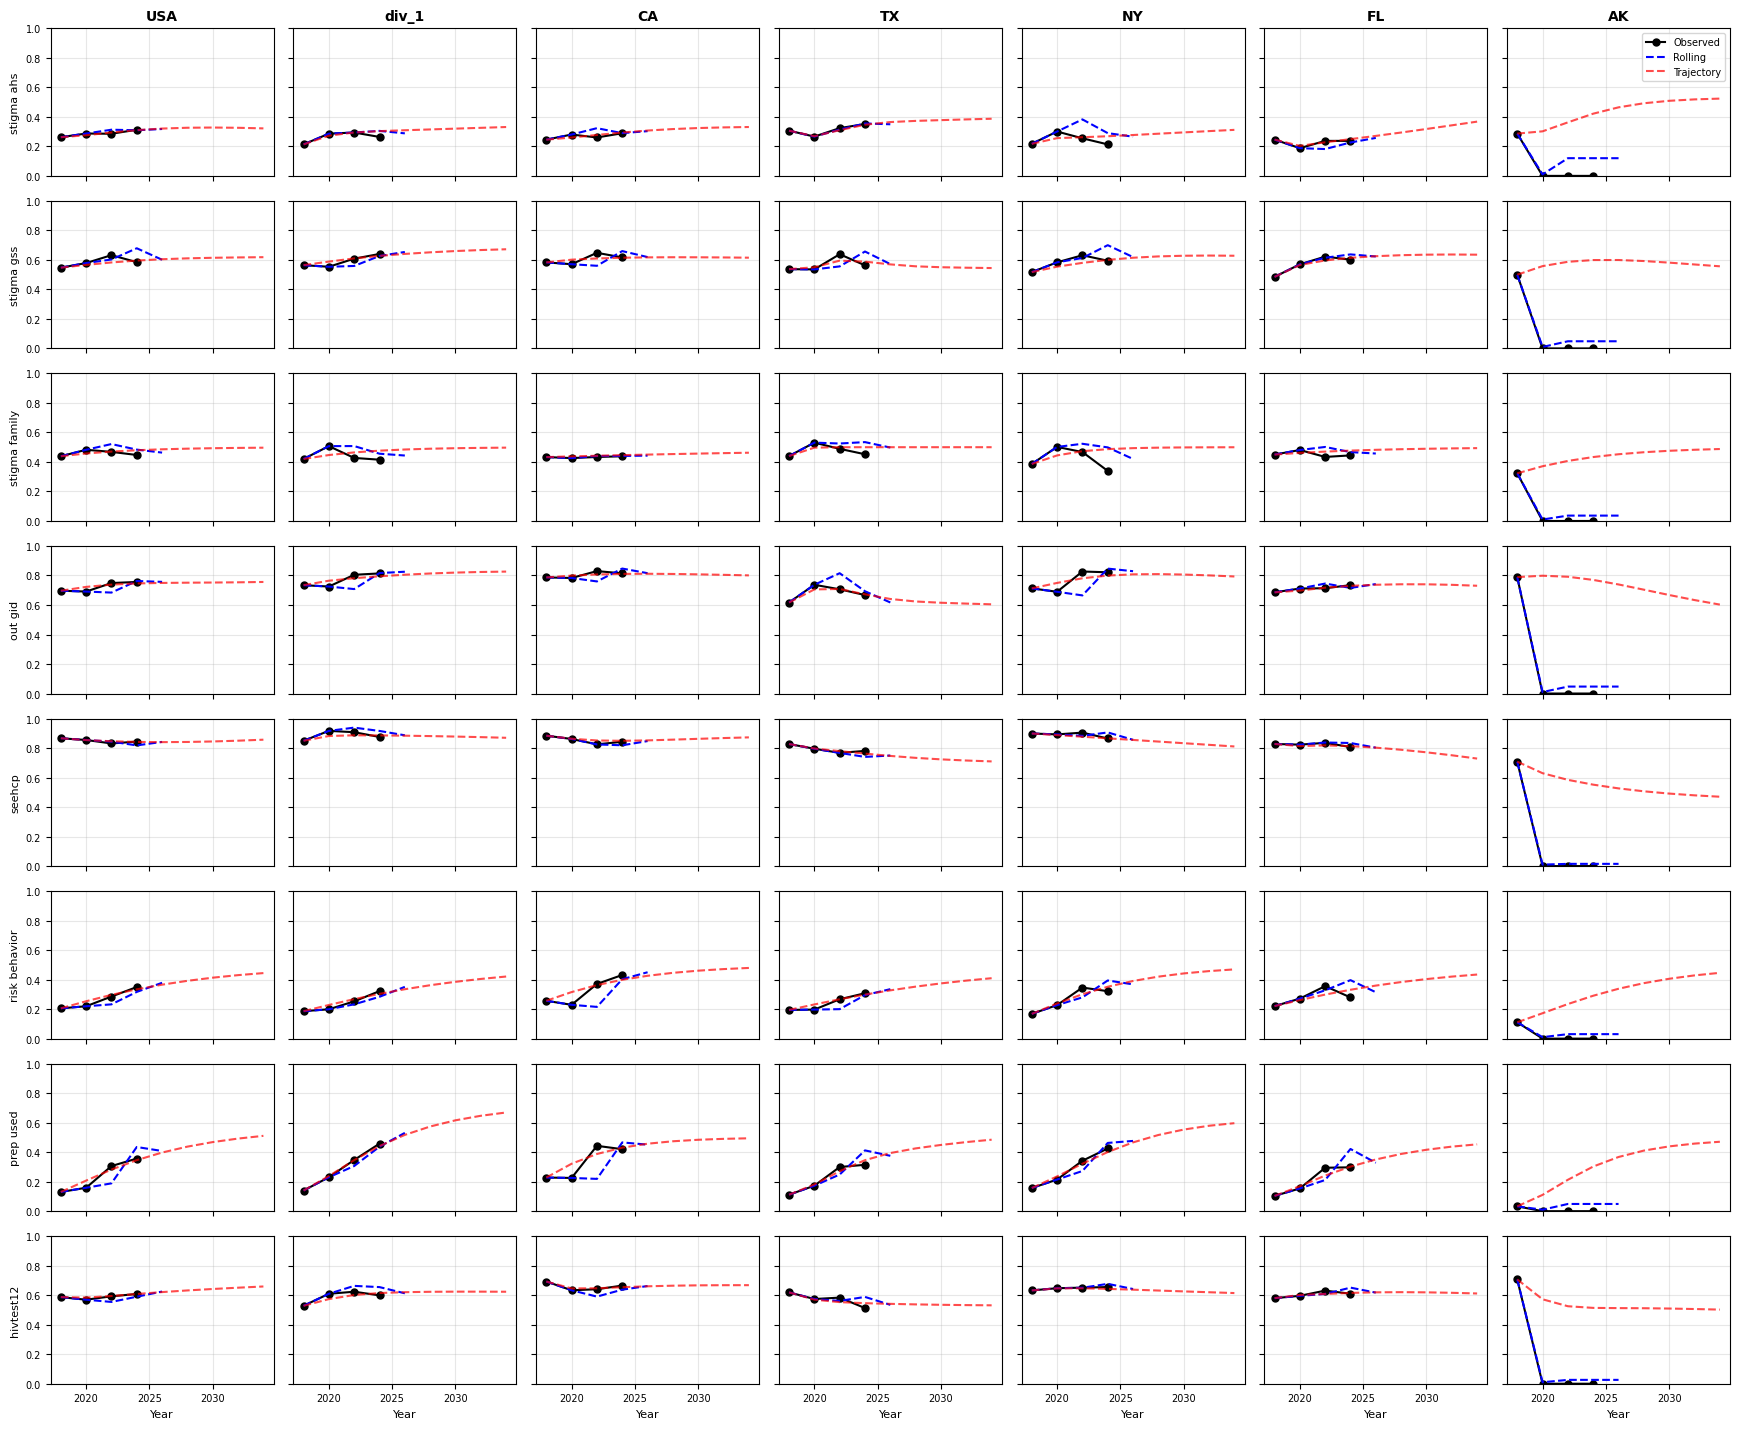

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("output/output.pkl", "rb") as f:
    output = pickle.load(f)

fit_results = output.fit
pred_results = output.predictions

units_to_plot = ["USA", "div_1", "CA", "TX", "NY", "FL", "AK"]

ts = np.array(fit_results.ts)
v_names = fit_results.v_names
m = len(v_names)
n_units = len(units_to_plot)
T_obs = len(ts)
dt = ts[1] - ts[0] if len(ts) > 1 else 2

# Time axes
ts_rolling = np.append(ts, ts[-1] + dt)  # T+1 points

pred_usa = pred_results.results["USA"]
n_total = pred_usa.Ypred_trajectory.shape[1]
ts_trajectory = ts[0] + dt * np.arange(n_total)  # Starts at first observed

print(f"ts_obs: {ts}")
print(f"ts_rolling: {ts_rolling}")
print(f"ts_trajectory: {ts_trajectory}")

fig, axes = plt.subplots(
    nrows=m,
    ncols=n_units,
    figsize=(2.5 * n_units, 1.8 * m),
    sharex=True,
    sharey="row",
)

for col, unit_id in enumerate(units_to_plot):
    fit_res = fit_results.results.get(unit_id)
    pred_res = pred_results.results.get(unit_id)

    if fit_res is None:
        print(f"Skipping {unit_id}")
        continue

    Ybar = fit_res.Ybar
    Ypred_rolling = pred_res.Ypred_rolling if pred_res else None
    Ypred_trajectory = pred_res.Ypred_trajectory if pred_res else None

    for row, var in enumerate(v_names):
        ax = axes[row, col]

        # Observed
        ax.plot(ts, Ybar[row, :], "ko-", ms=5, lw=1.5, label="Observed")

        # Rolling (one-step ahead using observed X)
        if Ypred_rolling is not None:
            ax.plot(ts_rolling, Ypred_rolling[row, :], "b--", lw=1.5, label="Rolling")

        # Trajectory (recursive simulation from X0)
        if Ypred_trajectory is not None:
            ax.plot(ts_trajectory, Ypred_trajectory[row, :], "r--", lw=1.5, alpha=0.7, label="Trajectory")

        if row == 0:
            ax.set_title(unit_id, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(var.replace("_", " "), fontsize=8)
        if row == m - 1:
            ax.set_xlabel("Year", fontsize=8)

        ax.set_ylim(0, 1)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)

axes[0, -1].legend(fontsize=7, loc="upper right")

plt.tight_layout()
# plt.savefig("output/test_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fit_usa = fit_results.results["USA"]

# J_sequence shape: (m, m, T)
J_sequence = fit_usa.J
print(f"J_sequence shape: {J_sequence.shape}")

# Last J from rolling sequence
J_rolling_last = J_sequence[:, :, -1]
print(f"\nJ_rolling_last (J[:,:,-1]):")
print(J_rolling_last)

# What J is used for trajectory?
# In runner: J_final = fit.J[:, :, -1]
J_trajectory = J_sequence[:, :, -1]
print(f"\nJ_trajectory (same as above):")


print(f"\nAre they the same? {np.allclose(J_rolling_last, J_trajectory)}")

J_sequence shape: (8, 8, 4)

J_rolling_last (J[:,:,-1]):
[[ 1.          0.0027325   0.06904453  0.16639955 -0.006597    0.
   0.         -0.13747356]
 [ 0.          1.          0.          0.02969859  0.          0.
   0.          0.        ]
 [ 0.          0.          1.          0.          0.          0.
   0.          0.        ]
 [-0.09617492  0.          0.          1.          0.          0.
   0.          0.0165467 ]
 [-0.07750493  0.          0.          0.          1.          0.
   0.1170779   0.10076782]
 [ 0.          0.          0.          0.          0.          1.
   0.          0.        ]
 [-0.05850038  0.          0.          0.          0.21402177  0.
   1.          0.        ]
 [ 0.          0.          0.          0.03361809  0.0328297   0.03021394
   0.01770375  1.        ]]

J_trajectory (same as above):
[[ 1.          0.0027325   0.06904453  0.16639955 -0.006597    0.
   0.         -0.13747356]
 [ 0.          1.          0.          0.02969859  0.          0.


In [33]:
import pandas as pd 
pd.DataFrame(J_trajectory, index=v_names, columns=v_names)

,stigma_ahs,stigma_gss,stigma_family,out_gid,seehcp,risk_behavior,prep_used,hivtest12
stigma_ahs,1.000000,0.002732,0.069045,0.166400,-0.006597,0.000000,0.000000,-0.137474
stigma_gss,0.000000,1.000000,0.000000,0.029699,0.000000,0.000000,0.000000,0.000000
stigma_family,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
out_gid,-0.096175,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.016547
seehcp,-0.077505,0.000000,0.000000,0.000000,1.000000,0.000000,0.117078,0.100768
risk_behavior,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
prep_used,-0.058500,0.000000,0.000000,0.000000,0.214022,0.000000,1.000000,0.000000
hivtest12,0.000000,0.000000,0.000000,0.033618,0.032830,0.030214,0.017704,1.000000


In [ ]:
        sign_matrix = np.array([
                [0, 1, 1, 1, -1, 0, 0, -1],
                [0, 0, 0, 1, 0, 0, 0, 0],
                [0, 1, 0, 0, 0, 0, 0, 0],
                [-1, 0, 0, 0, 0, 1, 0, 1],
                [-1, 0, 0, 0, 0, 0, 1, 1],
                [0, 0, 0, 0, 0, 0, 0, 0],
                [-1, 0, 0, 1, 1, 1, 0, 1],
                [0, 0, 0, 1, 1, 1, 1, 0]
            ])

NameError: name 'data' is not defined

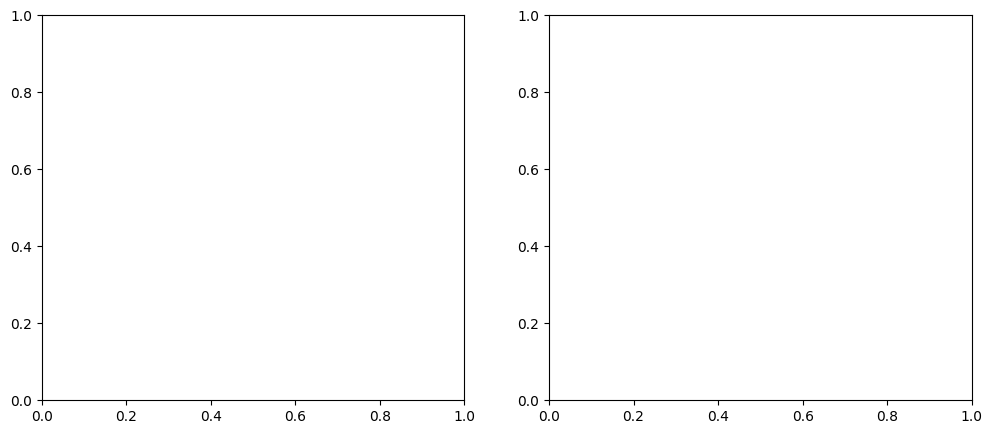

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
im = ax.imshow(data.M, cmap='Blues')
ax.set_xticks(range(len(data.v_names)))
ax.set_yticks(range(len(data.v_names)))
ax.set_xticklabels(data.v_names, rotation=45, ha='right')
ax.set_yticklabels(data.v_names)
ax.set_title('M (allowed relationships)')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.imshow(data.sign_mask, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(len(data.v_names)))
ax.set_yticks(range(len(data.v_names)))
ax.set_xticklabels(data.v_names, rotation=45, ha='right')
ax.set_yticklabels(data.v_names)
ax.set_title('sign_mask (expected directions)')
plt.colorbar(im, ax=ax)

plt.tight_layout()
# plt.savefig("output/M_and_sign_mask.png", dpi=150)
plt.show()